<img src='../OUTILS/bandeau_MF.png' align='right' width='100%'/>

<div style='background-color: #27ae60; color: white; padding: 20px; border-radius: 10px; text-align: center;'>
🌊🛰️ <b>Manipula​tion de données satellitaires - Température de surface de la mer (SST)</b>
</div>

---

## 🎯 **Objectifs du TP**

## 🔎  Analyser un fichier NetCDF (produit OSTIA) 
## 🖼️  Produire une image TIF/JPEG à partir de la SST 
## 🎨  Appliquer une palette de couleurs 
## 🔄  Reprojeter un planisphère dans différentes projections 

---

## 🧰 **Workflow : lignes de commandes bash (GDAL & ImageMagick)**

Ce TP utilise principalement la bibliothèque **GDAL** (*Geospatial Data Abstraction Library*) et **ImageMagick** pour manipuler les images.

Les fichiers utilisés sont des **NetCDF** de température de surface de la mer (SST) issus de la production **Copernicus** (OSTIA – UK Met Office).

<div class="alert alert-info" role="alert">
<h3> ⚙️ Initialisation de l'environnement</h3>
Importation des librairies et configuration des chemins d'accès.
</div>

In [ ]:
from datetime import datetime
import sys
import os
from osgeo import gdal
from PIL import Image
import subprocess
from IPython.display import display, HTML
os.environ['PATH'] = f"/opt/conda/env_MF_teledetection/bin:{os.environ['PATH']}" 
os.environ['PATH'] = f"~/.conda/envs/env_MF_teledetection/bin:{os.environ['PATH']}"
os.environ['GDAL_DATA'] = '/opt/conda/env_MF_teledetection/share/gdal'
os.environ['PROJ_LIB'] = '/opt/conda/env_MF_teledetection/share/proj'

<div class="alert alert-info alert-success">
<h3> 1️⃣ - 🔎 Analyse du fichier NetCDF OSTIA</h3>
</div>

📁 **Fichier source** : `/stockage/DATA/NetCDF/OSTIA/202604.nc`

In [ ]:
INPUT = "/stockage/DATA/NetCDF/OSTIA/202604.nc"
print(f"📁 Fichier source configuré : {INPUT}")

In [ ]:
cd ~/MF_DATA_MANIPULATION

In [ ]:
!pwd

In [ ]:
!mkdir -p RESULTS
output = 'RESULTS'

In [ ]:
!gdalinfo $INPUT

## 🌊 **Analyse détaillée du fichier NetCDF OSTIA**
### *Sea Surface Temperature (SST) - UK Met Office*

---

| Propriété | Valeur |
|-----------|--------|
| 📛 **Nom** | `202604.nc` |
| 🏛️ **Institution** | UKMO (UK Met Office) |
| 🛰️ **Produit** | OSTIA (Operational SST and Ice Analysis) |
| 📐 **Format** | NetCDF-4, CF-1.11 |
| 🎯 **Usage** | Température de surface de la mer (fondation) |

---

### 🌍 **Géoréférencement**

| Paramètre | Valeur |
|-----------|--------|
| 🗺️ **Projection** | Géographique WGS84 (directe) |
| 📏 **Résolution** | **0.05°** (≈ 5.5 km à l'équateur) |
| 📊 **Dimensions** | 7200 (lon) × 3600 (lat) |
| 🔄 **Emprise** | Globe entier : -180° ↔ 180° lon, -90° ↔ 90° lat |
| 📍 **Ordre coord.** | **Longitude puis latitude** (X,Y) |

> 💡 *Pas de projection complexe : les coordonnées sont directement en degrés !*

---

### 🌡️ **Variable principale : `analysed_sst`**

| Propriété | Valeur |
|-----------|--------|
| 🏷️ **Nom complet** | Analysed sea surface temperature |
| 📊 **Type** | Float32 (nombres décimaux 32 bits) |
| 📐 **Unité** | **Kelvin** (K) |
| ✅ **Min valide** | 270.15 K (-3.0°C) |
| ❌ **Max valide** | 318.15 K (45.0°C) |
| 🚫 **NoData** | `nan` (Not a Number) |

#### 🔁 Conversion en Celsius
```python
Celsius = Kelvin - 273.15
```

<div class="alert alert-info alert-success">
<h3> 2️⃣ - 🖼️ Production d'une image TIF à partir de la SST</h3>
</div>

### 🎨 **Étirement linéaire (contrast stretching)**

Nous transformons les valeurs de température (270 K à 318 K) en nuances de gris 8 bits (0-255) avec `gdal_translate` et l'option `-scale`.

In [ ]:
!gdal_translate -scale 270 318 0 255 -ot Byte $INPUT {output}/202604_sst_ostia.tif 2>/dev/null
!convert -resize 1000x500 {output}/202604_sst_ostia.tif {output}/202604_sst_ostia.jpg 2>/dev/null 
im1 = Image.open(output + '/202604_sst_ostia.jpg', 'r')
display(im1)

> 💡 *On peut resserrer la dynamique pour mieux visualiser les contrastes océaniques.*  
> Exemple : plage de -2,15 °C à 32,85 °C (271 K à 306 K)

Input file size is 7200, 3600
0...10...20...30...40...50...60...70...80...90...100 - done.


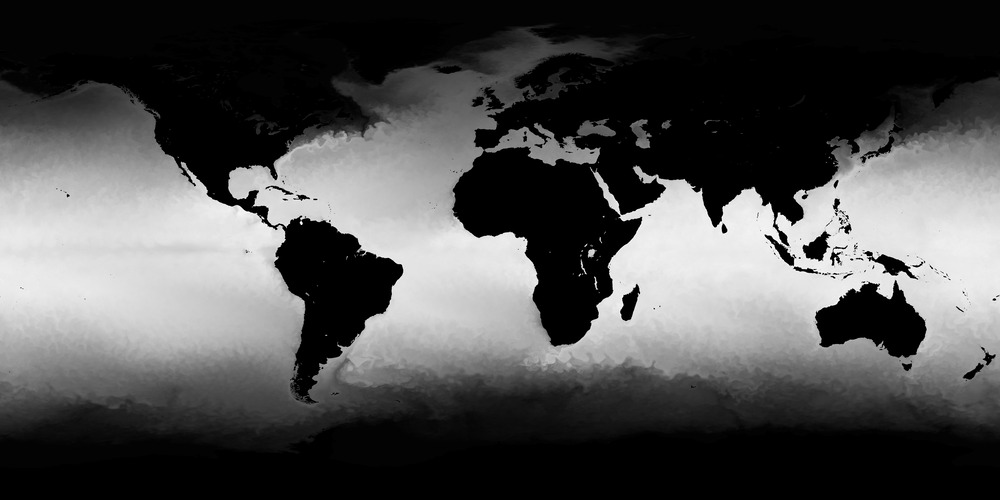

In [26]:
!gdal_translate -scale 271 306 0 255 -ot Byte $INPUT {output}/202604_sst_ostia_271_306.tif 2>/dev/null
!convert -resize 1000x500 {output}/202604_sst_ostia_271_306.tif {output}/202604_sst_ostia_271_306.jpg 2>/dev/null 
im2 = Image.open(output + '/202604_sst_ostia_271_306.jpg', 'r')
display(im2)

<div class="alert alert-info alert-success">
<h3> 3️⃣ - 🎨 Application d'une palette de couleurs</h3>
</div>

La commande `gdaldem color-relief` permet d'appliquer une palette (fichier texte) à une image en niveaux de gris.

In [ ]:
!gdal_translate $INPUT {output}/202604_sst_ostia_271_306.tif 2>/dev/null
!gdaldem color-relief {output}/202604_sst_ostia_271_306.tif OUTILS/palette_SST.txt {output}/202604_sst_ostia_palette.tif
!convert -resize 1000x500 {output}/202604_sst_ostia_palette.tif {output}/202604_sst_ostia_palette.jpg
im3 = Image.open(output + '/202604_sst_ostia_palette.jpg', 'r')
display(im3)

<div class="alert alert-info alert-success">
<h3> 4️⃣ - 🗺️ Ajout du fond de carte (Blue Marble)</h3>
</div>

Utilisation de l'image **NASA Blue Marble** (transparente) pour représenter les terres.</br>

Le produit “Blue Marble” de la NASA désigne une série d’images très détaillées de la Terre vues depuis l’espace, réalisées à partir de données satellites : Terra (Modis) principalement, puis NOAA (AVHRR), et ensuite Aqua et S-NPP.
Plusieurs mois d’images sont assemblés pour créer une mosaïque réaliste de notre planète. </br>
Des versions mensuelles sont disponibles, représentatives de la végétation associée.</br>
Une version de nuit existe : la "Black Marble" réalisée à partir des satellites DMSP Defense Meteorological Satellite Program.</br>
Ces images sont devenues emblématiques pour la visualisation scientifique, l’éducation et la sensibilisation à l’environnement.</br>
https://science.nasa.gov/earth/earth-observatory/collections/blue-marble/

In [ ]:
!convert -resize 1000x500 /stockage/DATA/bluemarble/bluemarble_transp_04.png {output}/bluemarble_transp_04_1000x500.png
im4 = Image.open(output + '/bluemarble_transp_04_1000x500.png', 'r')
display(im4)

Visualisation ci-dessus de la Blue Marble pour le mois d'avril

### 🔀 **Fusion avec l'image SST colorée**

In [ ]:
!composite -quiet -geometry +0+0 {output}/bluemarble_transp_04_1000x500.png {output}/202604_sst_ostia_palette.jpg {output}/202604_sst_ostia_bluemarble.jpg
im5 = Image.open(output + '/202604_sst_ostia_bluemarble.jpg', 'r')
display(im5)

> ⚠️ *La fusion via ImageMagick en JPG perd le géoréférencement. Pour les reprojections, il faut travailler en TIF géoréférencé.*

### 🗺️ **Reconstruction d'un TIF géoréférencé en haute résolution**

In [ ]:
dimension_planisphere = "3000x1500"

In [ ]:
!gdal_translate $INPUT {output}/202604_sst_ostia_271_306.tif 2>/dev/null
!gdaldem color-relief {output}/202604_sst_ostia_271_306.tif OUTILS/palette_SST.txt {output}/202604_sst_ostia_palette.tif
!convert -resize {dimension_planisphere} {output}/202604_sst_ostia_palette.tif {output}/202604_sst_ostia_palette_{dimension_planisphere}.jpg
!convert -resize {dimension_planisphere} /stockage/DATA/bluemarble/bluemarble_transp_04.png {output}/bluemarble_transp_04_{dimension_planisphere}.png
!composite -quiet -geometry +0+0 {output}/bluemarble_transp_04_{dimension_planisphere}.png {output}/202604_sst_ostia_palette_{dimension_planisphere}.jpg {output}/202604_sst_ostia_bluemarble_{dimension_planisphere}.tif
!gdal_translate -of GTiff -a_srs EPSG:4326 -a_ullr -180 90 180 -90 {output}/202604_sst_ostia_bluemarble_{dimension_planisphere}.tif {output}/202604_sst_ostia_bluemarble.tif

<div class="alert alert-info alert-success">
<h3> 5️⃣ - 🔄 Reprojection dans différents systèmes</h3>
</div>

| Projection | Type | Caractéristique principale | Inconvénient majeur | Commande GDAL |
|------------|------|---------------------------|---------------------|---------------|
| **Peters** | Cylindrique équivalente | Conserve les surfaces | Distorsion verticale extrême | `+proj=cea +lat_ts=45` |
| **Robinson** | Pseudocylindrique | Compromis harmonieux | Ni conforme, ni équivalente | `+proj=robin` |
| **Mollweide** | Pseudocylindrique équivalente | Conserve les surfaces, forme elliptique | Forte distorsion des angles | `+proj=moll` |

> 💡 *Aucune des trois n'a de code EPSG officiel, on utilise des chaînes PROJ.* </br>
> *Peters : Cylindrical Equal Area (cea) avec `lat_ts=0`* </br>
> *Robinson : utilisée par National Geographic (1988-1998)* </br>
> *Mollweide : idéale pour cartes thématiques globales* </br>


### 🗺️ **Projection de Peters**

In [ ]:
!gdalwarp -overwrite -t_srs "+proj=cea +lon_0=0 +lat_ts=45 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs" -r cubic {output}/202604_sst_ostia_bluemarble.tif {output}/202604_sst_ostia_bluemarble_peters.tif -co COMPRESS=LZW >/dev/null 2>&1
!convert -resize 1000 {output}/202604_sst_ostia_bluemarble_peters.tif {output}/202604_sst_ostia_bluemarble_peters.jpg >/dev/null 2>&1
im6 = Image.open(output + '/202604_sst_ostia_bluemarble_peters.jpg', 'r')
display(im6)

### 🗺️ **Projection de Robinson**

In [ ]:
!gdalwarp -t_srs "+proj=robin +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs" -r cubic {output}/202604_sst_ostia_bluemarble.tif {output}/202604_sst_ostia_bluemarble_robinson.tif -co COMPRESS=LZW >/dev/null 2>&1
!convert -resize 1000 {output}/202604_sst_ostia_bluemarble_robinson.tif {output}/202604_sst_ostia_bluemarble_robinson.jpg >/dev/null 2>&1
im7 = Image.open(output + '/202604_sst_ostia_bluemarble_robinson.jpg', 'r')
display(im7)

La projection de Robinson est une projection cartographique créée pour représenter le monde entier de manière « visuellement équilibrée ». 
Elle donne un planisphère agréable à visualiser, les continents ont une forme relativement naturelle. Elle est moins déformée qu'un "plate carrée" ou qu'une Mercator, mais elle ne conserve pas les surfaces comme le font Mollweide ou Peters

### 🗺️ **Projection de Mollweide**

In [ ]:
!gdalwarp -t_srs "+proj=moll +lon_0=0 +datum=WGS84 +units=m +no_defs" -r cubic {output}/202604_sst_ostia_bluemarble.tif {output}/202604_sst_ostia_bluemarble_mollweide.tif -co COMPRESS=LZW >/dev/null 2>&1
!convert -resize 1000 {output}/202604_sst_ostia_bluemarble_mollweide.tif {output}/202604_sst_ostia_bluemarble_mollweide.jpg >/dev/null 2>&1
im8 = Image.open(output + '/202604_sst_ostia_bluemarble_mollweide.jpg', 'r')
display(im8)

## Synthèse des projections planisphères les plus utilisées

## &emsp;  <img src='../DOCS/projections_ld.jpg' align='left' width='30%'/> 

### Différence Mercator et Lon/Lat

## &emsp;  <img src='../DOCS/projections_mercator_et_lon-lat.jpg' align='left' width='30%'/> 

### Zoom sur l'Europe

## &emsp;  <img src='../DOCS/projections_stereo_mercator_lonlat.jpg' align='left' width='30%'/>

### 🛰️ **Vue géostationnaire (simulation satellite)**

La position en longitude du satellite est indiquée par l'option `+lon_0`.</br>
Valeurs MTGI1 ici

In [ ]:
!gdalwarp -overwrite -r cubic -t_srs '+proj=geos +a=6378169 +b=6356583.8 +lon_0=0 +h=35785834 +x_0=0 +y_0=0' -te -5500000 -5500000 5500000 5500000 {output}/202604_sst_ostia_bluemarble.tif {output}/202604_sst_ostia_bluemarble_vue_geos_0.tif >/dev/null 2>&1
!convert -resize 1000 {output}/202604_sst_ostia_bluemarble_vue_geos_0.tif {output}/202604_sst_ostia_bluemarble_vue_geos_0.jpg >/dev/null 2>&1
im9 = Image.open(output + '/202604_sst_ostia_bluemarble_vue_geos_0.jpg', 'r')
display(im9)

### 🔄 **Projection `ob_tran` (Oblique Transformation)**

`ob_tran` permet de simuler un satellite géostationnaire à une latitude non nulle (ex: 40°N) alors que `geos` est limité à l'équateur.

In [ ]:
!gdalwarp -overwrite -r cubic -t_srs '+proj=ob_tran +o_proj=geos +o_lon_p=0 +o_lat_p=40 +lon_0=-30 +a=6378169 +b=6356583.8 +h=35785834 +x_0=0 +y_0=0' -te -5500000 -5500000 5500000 5500000 {output}/202604_sst_ostia_bluemarble.tif {output}/202604_sst_ostia_bluemarble_vue_geos_obtran.tif
!convert -resize 1000 {output}/202604_sst_ostia_bluemarble_vue_geos_obtran.tif {output}/202604_sst_ostia_bluemarble_vue_geos_obtran.jpg >/dev/null 2>&1
im10 = Image.open(output + '/202604_sst_ostia_bluemarble_vue_geos_obtran.jpg', 'r')
display(im10)

# Projection `ob_tran` (Oblique Transformation) avec GDAL

## Description
`ob_tran` permet de transformer n'importe quelle projection en lui appliquant une rotation/décalage (changement de pôle, point de vue satellite incliné). Pour un satellite géostationnaire, elle simule une latitude non nulle (ex: 40°N) alors que `geos` est limité à l'équateur.

## Syntaxe 


## Options détaillées

| Option | Type | Plage | Description |
|--------|------|-------|-------------|
| `+o_proj` | string | - | Projection d'origine (ex: `geos`, `merc`, `longlat`, `ortho`) |
| `+o_lat_p` | float | -90°..90° | Latitude du nouveau pôle/point d'observation (défaut=0) |
| `+o_lon_p` | float | -180°..180° | Longitude du nouveau pôle (défaut=0) |
| `+lon_0` | float | -180°..180° | Méridien central de la projection résultante (défaut=0) |
| `+o_alpha` | float | 0°..360° | Rotation supplémentaire autour du nouveau pôle (défaut=0) |
| `+k` | float | >0 | Facteur d'échelle (défaut=1) |
| `+x_0`, `+y_0` | float | - | Fausses coordonnées (m) |

## Options héritées de `geos` (si `+o_proj=geos`)

| Option | Valeur standard | Signification |
|--------|-----------------|---------------|
| `+h` | 35785834 m | Altitude satellite |
| `+a` | 6378169 m | Demi-grand axe |
| `+b` | 6356583.8 m | Demi-petit axe |
| `+units` | m | Unités |

## Exemples

---

## 🔗 **Ressources complémentaires - Aller plus loin à propose de la SST**


## OSISAT [OSI SAF](https://osi-saf.eumetsat.int/) 
## Tutoriel interactif (Notebook) [Jupyter Notebook OSI SAF](https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-osi-saf-sst)  

---

✅ **Fin du TP**